In [26]:
import os
import sys
from pathlib import Path 

from pyspark.sql import SparkSession
from pyspark.sql import functions as F 
from pyspark.sql.window import Window
from dotenv import load_dotenv

import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 



In [27]:
load_dotenv()

BASE_DIR = Path().resolve().parent

In [28]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SerumQA-EDA")
    .config("spark.jars", str(BASE_DIR / "drivers" / "postgresql-42.7.3.jar"))
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

In [29]:
spark.stop()

spark = (                                                                                                                                                                           
    SparkSession.builder
    .master("local[*]")                                                                                                                                                             
    .appName("SerumQA-EDA")
    .config("spark.jars", str(BASE_DIR / "drivers" / "postgresql-42.7.3.jar"))                                                                                                      
    .config("spark.sql.shuffle.partitions", "8")                                                                                                                                    
    .getOrCreate()                                                                                                                                                                  
)                                                                                                                                                                                   
                
print("Spark restarted with JDBC jar.")

Spark restarted with JDBC jar.


In [30]:
jdbc_url = (
    f"jdbc:postgresql://"
    f"{os.getenv('POSTGRES_HOST', 'localhost')}:"
    f"{os.getenv('POSTGRES_PORT', '5433')}/"
    f"{os.getenv('POSTGRES_DB')}"
)

In [31]:
properties = {
    "user": os.getenv("POSTGRES_USER"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "driver": "org.postgresql.Driver",
}

In [33]:
bronze_df = spark.read.jdbc(jdbc_url, "bronze.qa_events", properties=properties)

print(f"Bronze rows: {bronze_df.count():,}")

Bronze rows: 439,652


In [37]:
silver_df = spark.read.jdbc(jdbc_url, "silver.qa_events_clean", properties=properties)

print(f"Silver rows: {silver_df.count():,}")     

Silver rows: 431,068


In [39]:
gold_df = spark.read.jdbc(jdbc_url, "gold.qa_features", properties=properties)

print(f"Gold rows: {gold_df.count():,}")     

Gold rows: 431,068


In [40]:
print("=== BRONZE SCHEMA ===")
bronze_df.printSchema()

=== BRONZE SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- source_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- product: string (nullable = true)
 |-- system: string (nullable = true)
 |-- root_cause: string (nullable = true)
 |-- severity: string (nullable = true)
 |-- batch_id: string (nullable = true)
 |-- status: string (nullable = true)
 |-- resolution_days: double (nullable = true)
 |-- closed_timestamp: timestamp (nullable = true)
 |-- is_anomaly: integer (nullable = true)
 |-- is_covid_period: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- cdc_operation: string (nullable = true)
 |-- cdc_ingested_at: timestamp (nullable = true)



In [41]:
print("=== BASIC STATS ===")
bronze_df.describe().show()

=== BASIC STATS ===


26/04/15 16:42:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------+-----------------+----------------+---------+-----------+--------+----------+-------------------+------------------+--------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------+
|summary|                id|         source_id|  event_type|         event_id|         product|   system| root_cause|severity|  batch_id|             status|   resolution_days|          is_anomaly|   is_covid_period|              hour|       day_of_week|             month|              year|         is_weekend|cdc_operation|
+-------+------------------+------------------+------------+-----------------+----------------+---------+-----------+--------+----------+-------------------+------------------+--------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------+
|  count|          

In [43]:
print("=== NULL COUNTS ===")
bronze_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in bronze_df.columns
]).show(vertical=True)

=== NULL COUNTS ===


-RECORD 0------------------
 id               | 0      
 source_id        | 0      
 timestamp        | 0      
 event_type       | 0      
 event_id         | 0      
 product          | 22234  
 system           | 23259  
 root_cause       | 30545  
 severity         | 0      
 batch_id         | 405714 
 status           | 0      
 resolution_days  | 39762  
 closed_timestamp | 439652 
 is_anomaly       | 0      
 is_covid_period  | 0      
 hour             | 0      
 day_of_week      | 0      
 month            | 0      
 year             | 0      
 is_weekend       | 0      
 cdc_operation    | 439652 
 cdc_ingested_at  | 0      



In [44]:
print("=== DUPLICATE CHECK ===")
total = bronze_df.count()
distinct = bronze_df.dropDuplicates(["event_id", "timestamp"]).count()

print(f"Total rows: {total:,}")
print(f"Distinct rows: {distinct:,}")
print(f"Duplicates rows: {total - distinct:,}")

=== DUPLICATE CHECK ===


Total rows: 439,652
Distinct rows: 431,068
Duplicates rows: 8,584


In [45]:
print("=== SEVERITY DISTRIBUTION ===")
bronze_df.groupBy("severity").count().orderBy("count", ascending=False).show()

=== SEVERITY DISTRIBUTION ===


+--------+------+
|severity| count|
+--------+------+
|   Minor|277653|
|   Major|112163|
|Critical| 49836|
+--------+------+



In [46]:
print("=== EVENT TYPE DISTRIBUTION ===")

bronze_df.groupBy("event_type").count().orderBy("count", ascending=False).show()

=== EVENT TYPE DISTRIBUTION ===
+--------------+------+
|    event_type| count|
+--------------+------+
|change_control|382535|
|     deviation| 29382|
|          capa| 19484|
|           oos|  3989|
|     complaint|  1523|
|           ade|  1297|
|critical_alarm|  1008|
|  vendor_audit|   277|
|    media_fill|   157|
+--------------+------+



In [47]:
print("=== ANOMALY RATE OVERALL ===")
bronze_df.groupBy("is_anomaly").count().show()

=== ANOMALY RATE OVERALL ===


+----------+------+
|is_anomaly| count|
+----------+------+
|         1|  2041|
|         0|437611|
+----------+------+



In [48]:
print("=== ANOMALY RATE BY EVENT TYPE ===")
bronze_df.groupBy("event_type", "is_anomaly").count().orderBy("event_type", "is_anomaly").show()

=== ANOMALY RATE BY EVENT TYPE ===


+--------------+----------+------+
|    event_type|is_anomaly| count|
+--------------+----------+------+
|           ade|         0|  1297|
|          capa|         0| 19484|
|change_control|         0|382535|
|     complaint|         0|  1523|
|critical_alarm|         0|   906|
|critical_alarm|         1|   102|
|     deviation|         0| 27492|
|     deviation|         1|  1890|
|    media_fill|         0|   131|
|    media_fill|         1|    26|
|           oos|         0|  3989|
|  vendor_audit|         0|   254|
|  vendor_audit|         1|    23|
+--------------+----------+------+



In [49]:
anomaly_pd = bronze_df.groupBy("event_type", "is_anomaly").count().toPandas()

anomaly_only = anomaly_pd[anomaly_pd["is_anomaly"] == 1].sort_values("count", ascending=False)

/tmp/ipykernel_543837/3068534948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anomaly_only, x="event_type", y="count", palette="Reds_r")


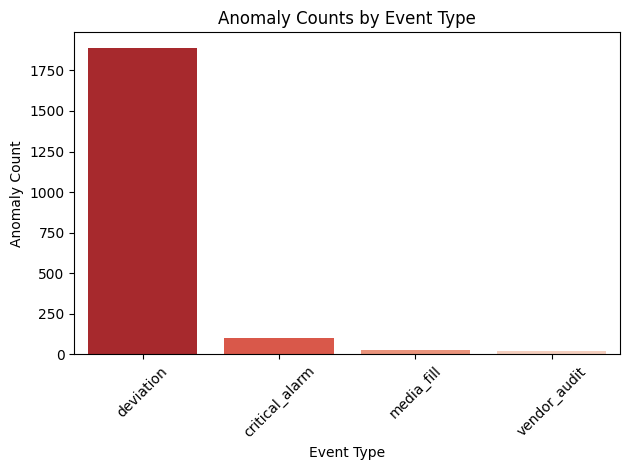

In [50]:
plt.Figure(figsize=(10,5))
sns.barplot(data=anomaly_only, x="event_type", y="count", palette="Reds_r")
plt.title("Anomaly Counts by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Anomaly Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
print("=== ANOMALIES BY YEAR ===")

bronze_df.filter(F.col("is_anomaly") == 1).groupBy("year").count().orderBy("year").show()

=== ANOMALIES BY YEAR ===


+----+-----+
|year|count|
+----+-----+
|2020|  478|
|2021|  676|
|2022|  292|
|2023|  161|
|2024|  325|
|2025|  109|
+----+-----+



In [52]:
anomaly_year_pd = bronze_df.filter(F.col("is_anomaly") == 1).groupBy("year").count().orderBy("year").toPandas()

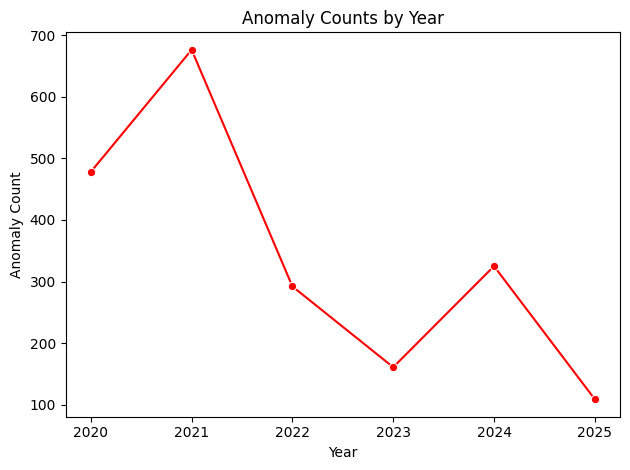

In [54]:
plt.Figure(figsize=(10,5))
sns.lineplot(data=anomaly_year_pd, x="year", y="count", marker="o", color="red")
plt.title("Anomaly Counts by Year")
plt.xlabel("Year")
plt.ylabel("Anomaly Count")
plt.xticks(anomaly_year_pd["year"])
plt.tight_layout()
plt.show()

In [62]:
anomaly_system_pd = bronze_df.filter(F.col("is_anomaly") == 1).groupBy("system").count().orderBy("count", ascending=False).toPandas()

In [63]:
print("=== ANOMALIES BY SYSTEM ===")

anomaly_system_pd = bronze_df.filter(F.col("is_anomaly") == 1).groupBy("system").count().orderBy("count", ascending=False).show()

=== ANOMALIES BY SYSTEM ===
+--------------+-----+
|        system|count|
+--------------+-----+
|       Filling|  578|
|       Capping|  430|
|      Blending|  304|
|Lyophilization|  261|
|        QC Lab|  207|
|          NULL|  155|
|     Warehouse|   68|
| Manufacturing|   38|
+--------------+-----+



In [59]:
anomaly_system_pd.columns = ["manufacturing_system", "count"]

/tmp/ipykernel_543837/2551373254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anomaly_system_pd, x="manufacturing_system", y="count", palette="Blues_r")


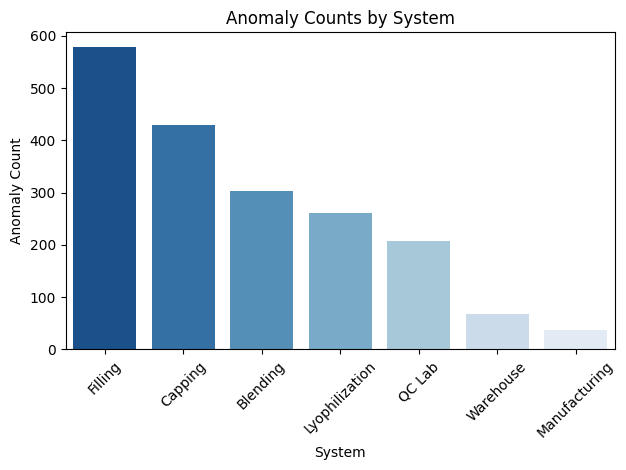

In [61]:
plt.Figure(figsize=(10,5))
sns.barplot(data=anomaly_system_pd, x="manufacturing_system", y="count", palette="Blues_r")
plt.title("Anomaly Counts by System")
plt.xlabel("System")
plt.ylabel("Anomaly Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
spark.stop()

print("Spark session stopped.")

Spark session stopped.
